### `Load the CSV file into a DataFrame`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


# Load the CSV file into a DataFrame
# 手動掛接訓練CSV檔案
# df = pd.read_csv('/content/Data_中英欄位.csv')

df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位.csv')
# df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位_simplified.csv')
# df
display(df.shape)

# print("Displaying the first 10 rows of 'df' to verify column names:")
# display(df.head(10))

Mounted at /content/drive


(5200, 57)

### 選取特徵X與目標變數Y 切分訓練/測試資料集

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable y
y = df['Supplier Risk（供應商風險等級）']


# Define the features X with only 'Supplier ESG Score（供應商ESG評分）' and 'PO Status（採購單狀態）'
X_selected = df[[
        'Supplier Tier（供應商層級）',
        'Maverick Spend（脫軌採購）',
        'Preferred Supplier（優先供應商）',
        'Days Late（延誤天數）',

        # bad feature importance
        'On Time Delivery（是否準時交貨）',
        'Invoice Status（發票狀態）',
        'Payment Status（付款狀態）',
        'Single Source Flag（單一來源標記）',
        'PO Type（採購單類型）',
        'Contract Type（合約類型）',
        'PO Status（採購單狀態）',

        # strong data leakage
        'Supplier ESG Score（供應商ESG評分）', # Removed due to strong data leakage with target variable
        ]]


# Handle categorical features in X_selected by one-hot encoding 'PO Status（採購單狀態）'
categorical_cols_selected = X_selected.select_dtypes(include='object').columns

if not categorical_cols_selected.empty:
    print(f"對以下類別特徵進行獨熱編碼: {list(categorical_cols_selected)}")
    X_selected = pd.get_dummies(X_selected, columns=categorical_cols_selected, drop_first=True)
else:
    print("沒有找到需要進行獨熱編碼的類別特徵。")

# Perform the train-test split (70% training, 30% testing)
# Using stratify=y to maintain the proportion of 'Supplier Risk' classes in both sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y, test_size=0.3, random_state=1, stratify=y
)

print(f"\n選取特徵後的 X 形狀: {X_selected.shape}")
print(f"目標變數 y 形狀: {y.shape}")

print(f"\n訓練特徵集 (X_train_selected) 形狀: {X_train_selected.shape}")
print(f"測試特徵集 (X_test_selected) 形狀: {X_test_selected.shape}")

print(f"訓練目標變數 (y_train_selected) 形狀: {y_train_selected.shape}")
print(f"測試目標變數 (y_test_selected) 形狀: {y_test_selected.shape}")

對以下類別特徵進行獨熱編碼: ['Maverick Spend（脫軌採購）', 'Preferred Supplier（優先供應商）', 'On Time Delivery（是否準時交貨）', 'Invoice Status（發票狀態）', 'Payment Status（付款狀態）', 'Single Source Flag（單一來源標記）', 'PO Type（採購單類型）', 'Contract Type（合約類型）', 'PO Status（採購單狀態）']

選取特徵後的 X 形狀: (5200, 22)
目標變數 y 形狀: (5200,)

訓練特徵集 (X_train_selected) 形狀: (3640, 22)
測試特徵集 (X_test_selected) 形狀: (1560, 22)
訓練目標變數 (y_train_selected) 形狀: (3640,)
測試目標變數 (y_test_selected) 形狀: (1560,)


## 使用 `X_selected` 特徵縮放 (Feature Scaling) Standardization and Normalization

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd


print("標準化和正規化前的訓練集形狀: ", X_train_selected.shape)
print("標準化和正規化前的測試集形狀: ", X_test_selected.shape)


print("--- 開始進行特徵標準化和正規化 ---")
# 1. 特徵標準化 (Standardization)
# 使用 StandardScaler 將特徵縮放到均值為0，標準差為1。
print("開始進行特徵標準化 (X_selected)...")
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

X_train_selected_std = scaler_selected.fit_transform(X_train_selected)
X_test_selected_std = scaler_selected.transform(X_test_selected)
print("特徵標準化完成。")




# 2. 特徵正規化 (Normalization)
# 在標準化後的數據上應用 MinMaxScaler，將數據縮放到0到1的範圍。
print("\n開始進行特徵正規化 (X_selected_std)...")
normalizer_selected = MinMaxScaler()
# X_train_selected_normalized = normalizer_selected.fit_transform(X_train_selected_scaled)
# X_test_selected_normalized = normalizer_selected.transform(X_test_selected_scaled)
X_train_selected_normalized = normalizer_selected.fit_transform(X_train_selected_std)
X_test_selected_normalized = normalizer_selected.transform(X_test_selected_std)
print("特徵正規化完成。")

print("標準化和正規化後的訓練集形狀: ", X_train_selected_normalized.shape)
print("標準化和正規化後的測試集形狀: ", X_test_selected_normalized.shape)

標準化和正規化前的訓練集形狀:  (3640, 22)
標準化和正規化前的測試集形狀:  (1560, 22)
--- 開始進行特徵標準化和正規化 ---
開始進行特徵標準化 (X_selected)...
特徵標準化完成。

開始進行特徵正規化 (X_selected_std)...
特徵正規化完成。
標準化和正規化後的訓練集形狀:  (3640, 22)
標準化和正規化後的測試集形狀:  (1560, 22)


### 檢查標準化及正規化後的數據

In [5]:
import pandas as pd

print("--- 檢查標準化後的數據 (X_train_selected_std) ---")
display(pd.DataFrame(X_train_selected_std, columns=X_train_selected.columns).describe())

print("\n--- 檢查標準化後的數據 (X_test_selected_std) ---")
display(pd.DataFrame(X_test_selected_std, columns=X_test_selected.columns).describe())

print("\n--- 檢查正規化後的數據 (X_train_selected_normalized) ---")
display(pd.DataFrame(X_train_selected_normalized, columns=X_train_selected.columns).describe())

print("\n--- 檢查正規化後的數據 (X_test_selected_normalized) ---")
display(pd.DataFrame(X_test_selected_normalized, columns=X_test_selected.columns).describe())

--- 檢查標準化後的數據 (X_train_selected_std) ---


,Supplier Tier（供應商層級）,Days Late（延誤天數）,Supplier ESG Score（供應商ESG評分）,Maverick Spend（脫軌採購）_Yes,Preferred Supplier（優先供應商）_Yes,On Time Delivery（是否準時交貨）_Yes,Invoice Status（發票狀態）_Overdue,Invoice Status（發票狀態）_Paid,Invoice Status（發票狀態）_Pending,Payment Status（付款狀態）_Overdue,...,Single Source Flag（單一來源標記）_Yes,PO Type（採購單類型）_Contract,PO Type（採購單類型）_Emergency,PO Type（採購單類型）_Standard,Contract Type（合約類型）_Long-term,Contract Type（合約類型）_Master Supply,Contract Type（合約類型）_Spot,PO Status（採購單狀態）_Closed,PO Status（採購單狀態）_Disputed,PO Status（採購單狀態）_Open
count,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,...,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03,3.640000e+03
mean,-2.732857e-17,-3.196466e-17,-3.308709e-16,5.856121e-18,-1.952040e-17,-5.734119e-17,2.732857e-17,4.733698e-17,-9.174590e-17,-3.123265e-17,...,1.659234e-17,-2.537653e-17,-1.317627e-17,1.873959e-16,-4.099285e-17,-5.270509e-17,8.100968e-17,1.049222e-17,3.513673e-17,6.539336e-17
std,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,...,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00,1.000137e+00
min,-1.226658e+00,-8.761765e-01,-1.222432e+00,-3.770145e-01,-6.934542e-01,-1.354581e+00,-4.232474e-01,-6.817542e-01,-8.258754e-01,-4.146388e-01,...,-3.660005e-01,-3.363775e-01,-3.323149e-01,-1.245314e+00,-4.455908e-01,-4.429311e-01,-1.031258e+00,-1.227553e+00,-2.333692e-01,-5.688905e-01
25%,-1.226658e+00,-6.786060e-01,-1.005065e+00,-3.770145e-01,-6.934542e-01,-1.354581e+00,-4.232474e-01,-6.817542e-01,-8.258754e-01,-4.146388e-01,...,-3.660005e-01,-3.363775e-01,-3.323149e-01,-1.245314e+00,-4.455908e-01,-4.429311e-01,-1.031258e+00,-1.227553e+00,-2.333692e-01,-5.688905e-01
50%,1.752369e-01,-4.810354e-01,-3.465739e-01,-3.770145e-01,-6.934542e-01,7.382354e-01,-4.232474e-01,-6.817542e-01,-8.258754e-01,-4.146388e-01,...,-3.660005e-01,-3.363775e-01,-3.323149e-01,8.030106e-01,-4.455908e-01,-4.429311e-01,9.696899e-01,8.146286e-01,-2.333692e-01,-5.688905e-01
75%,1.752369e-01,5.068173e-01,9.704091e-01,-3.770145e-01,1.442056e+00,7.382354e-01,-4.232474e-01,1.466804e+00,1.210836e+00,-4.146388e-01,...,-3.660005e-01,-3.363775e-01,-3.323149e-01,8.030106e-01,-4.455908e-01,-4.429311e-01,9.696899e-01,8.146286e-01,-2.333692e-01,-5.688905e-01
max,1.577132e+00,2.581308e+00,1.827087e+00,2.652418e+00,1.442056e+00,7.382354e-01,2.362685e+00,1.466804e+00,1.210836e+00,2.411738e+00,...,2.732236e+00,2.972850e+00,3.009194e+00,8.030106e-01,2.244211e+00,2.257687e+00,9.696899e-01,8.146286e-01,4.285056e+00,1.757808e+00



--- 檢查標準化後的數據 (X_test_selected_std) ---


,Supplier Tier（供應商層級）,Days Late（延誤天數）,Supplier ESG Score（供應商ESG評分）,Maverick Spend（脫軌採購）_Yes,Preferred Supplier（優先供應商）_Yes,On Time Delivery（是否準時交貨）_Yes,Invoice Status（發票狀態）_Overdue,Invoice Status（發票狀態）_Paid,Invoice Status（發票狀態）_Pending,Payment Status（付款狀態）_Overdue,...,Single Source Flag（單一來源標記）_Yes,PO Type（採購單類型）_Contract,PO Type（採購單類型）_Emergency,PO Type（採購單類型）_Standard,Contract Type（合約類型）_Long-term,Contract Type（合約類型）_Master Supply,Contract Type（合約類型）_Spot,PO Status（採購單狀態）_Closed,PO Status（採購單狀態）_Disputed,PO Status（採購單狀態）_Open
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,...,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,-0.012581,0.068933,-0.038995,0.005548,0.019752,-0.041205,0.030360,0.004132,-0.028163,-0.016047,...,0.005391,-0.013940,0.025398,-0.003189,-0.002463,0.000247,0.007696,-0.041517,-0.016137,0.030682
std,1.007373,1.041140,0.986911,1.006600,1.007495,1.012104,1.028901,1.001933,0.994484,0.984030,...,1.006666,0.981667,1.033454,1.001021,0.998099,1.000545,1.000054,1.008003,0.966931,1.017940
min,-1.226658,-0.876176,-1.222432,-0.377015,-0.693454,-1.354581,-0.423247,-0.681754,-0.825875,-0.414639,...,-0.366001,-0.336378,-0.332315,-1.245314,-0.445591,-0.442931,-1.031258,-1.227553,-0.233369,-0.568890
25%,-1.226658,-0.678606,-1.005065,-0.377015,-0.693454,-1.354581,-0.423247,-0.681754,-0.825875,-0.414639,...,-0.366001,-0.336378,-0.332315,-1.245314,-0.445591,-0.442931,-1.031258,-1.227553,-0.233369,-0.568890
50%,0.175237,-0.481035,-0.346574,-0.377015,-0.693454,0.738235,-0.423247,-0.681754,-0.825875,-0.414639,...,-0.366001,-0.336378,-0.332315,0.803011,-0.445591,-0.442931,0.969690,0.814629,-0.233369,-0.568890
75%,0.175237,0.803173,0.970409,-0.377015,1.442056,0.738235,-0.423247,1.466804,1.210836,-0.414639,...,-0.366001,-0.336378,-0.332315,0.803011,-0.445591,-0.442931,0.969690,0.814629,-0.233369,1.757808
max,1.577132,2.581308,1.827087,2.652418,1.442056,0.738235,2.362685,1.466804,1.210836,2.411738,...,2.732236,2.972850,3.009194,0.803011,2.244211,2.257687,0.969690,0.814629,4.285056,1.757808



--- 檢查正規化後的數據 (X_train_selected_normalized) ---


,Supplier Tier（供應商層級）,Days Late（延誤天數）,Supplier ESG Score（供應商ESG評分）,Maverick Spend（脫軌採購）_Yes,Preferred Supplier（優先供應商）_Yes,On Time Delivery（是否準時交貨）_Yes,Invoice Status（發票狀態）_Overdue,Invoice Status（發票狀態）_Paid,Invoice Status（發票狀態）_Pending,Payment Status（付款狀態）_Overdue,...,Single Source Flag（單一來源標記）_Yes,PO Type（採購單類型）_Contract,PO Type（採購單類型）_Emergency,PO Type（採購單類型）_Standard,Contract Type（合約類型）_Long-term,Contract Type（合約類型）_Master Supply,Contract Type（合約類型）_Spot,PO Status（採購單狀態）_Closed,PO Status（採購單狀態）_Disputed,PO Status（採購單狀態）_Open
count,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,...,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000,3640.000000
mean,0.437500,0.253414,0.400860,0.124451,0.324725,0.647253,0.151923,0.317308,0.405495,0.146703,...,0.118132,0.101648,0.099451,0.607967,0.165659,0.164011,0.515385,0.601099,0.051648,0.244505
std,0.356709,0.289267,0.327966,0.330140,0.468336,0.477891,0.358996,0.465492,0.491055,0.353859,...,0.322809,0.302227,0.299307,0.488271,0.371826,0.370336,0.499832,0.489740,0.221346,0.429853
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.057143,0.071279,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.114286,0.287212,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,0.500000,0.400000,0.719078,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- 檢查正規化後的數據 (X_test_selected_normalized) ---


,Supplier Tier（供應商層級）,Days Late（延誤天數）,Supplier ESG Score（供應商ESG評分）,Maverick Spend（脫軌採購）_Yes,Preferred Supplier（優先供應商）_Yes,On Time Delivery（是否準時交貨）_Yes,Invoice Status（發票狀態）_Overdue,Invoice Status（發票狀態）_Paid,Invoice Status（發票狀態）_Pending,Payment Status（付款狀態）_Overdue,...,Single Source Flag（單一來源標記）_Yes,PO Type（採購單類型）_Contract,PO Type（採購單類型）_Emergency,PO Type（採購單類型）_Standard,Contract Type（合約類型）_Long-term,Contract Type（合約類型）_Master Supply,Contract Type（合約類型）_Spot,PO Status（採購單狀態）_Closed,PO Status（採購單狀態）_Disputed,PO Status（採購單狀態）_Open
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,...,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,0.433013,0.273352,0.388073,0.126282,0.333974,0.627564,0.162821,0.319231,0.391667,0.141026,...,0.119872,0.097436,0.107051,0.606410,0.164744,0.164103,0.519231,0.580769,0.048077,0.257692
std,0.359290,0.301126,0.323628,0.332273,0.471782,0.483609,0.369320,0.466328,0.488279,0.348160,...,0.324916,0.296645,0.309278,0.488702,0.371068,0.370487,0.499790,0.493591,0.213997,0.437504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.057143,0.071279,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.114286,0.287212,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,0.500000,0.485714,0.719078,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
'''
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

# 1. 特徵縮放 (Feature Scaling)
# Logistic Regression 對於未縮放的特徵比較敏感。
print("開始進行特徵標準化 (X_selected)...")
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)
print("特徵標準化完成。")
'''

'''
# 2. 初始化邏輯回歸模型
#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。
#   - class_weight='balanced': 自動調整類別權重，以應對類別不平衡問題。
model_selected = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

# 3. 訓練模型
print("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")
model_selected.fit(X_train_selected_scaled, y_train_selected)
print("模型訓練完成。")

# 4. 進行預測
y_pred_selected = model_selected.predict(X_test_selected_scaled)

# 5. 評估模型性能
print("\n--- 模型評估 (使用 X_selected) ---")

# 準確度
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
print(f"準確度 (Accuracy): {accuracy_selected:.4f}")

# 分類報告 (包含精確度、召回率、F1-score)
print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected))

# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")
cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)
display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model_selected.classes_)
display_cm_selected.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression (X_selected)')
plt.show()
'''

'\n# 2. 初始化邏輯回歸模型\n#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。\n#   - class_weight=\'balanced\': 自動調整類別權重，以應對類別不平衡問題。\nmodel_selected = LogisticRegression(max_iter=5000, random_state=42, class_weight=\'balanced\')\n\n# 3. 訓練模型\nprint("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")\nmodel_selected.fit(X_train_selected_scaled, y_train_selected)\nprint("模型訓練完成。")\n\n# 4. 進行預測\ny_pred_selected = model_selected.predict(X_test_selected_scaled)\n\n# 5. 評估模型性能\nprint("\n--- 模型評估 (使用 X_selected) ---")\n\n# 準確度\naccuracy_selected = accuracy_score(y_test_selected, y_pred_selected)\nprint(f"準確度 (Accuracy): {accuracy_selected:.4f}")\n\n# 分類報告 (包含精確度、召回率、F1-score)\nprint("\n分類報告 (Classification Report):\n")\nprint(classification_report(y_test_selected, y_pred_selected))\n\n# 混淆矩陣\nprint("\n混淆矩陣 (Confusion Matrix):\n")\ncm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)\ndisplay_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selecte

In [7]:
'''
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Function for Min-Max Normalization
def min_max_normalize(series):
    if series.empty or series.nunique() == 1:
        return series # Return original if empty or only one unique value
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Function for Z-score Standardization
def z_score_standardize(series):
    if series.empty or series.std() == 0:
        return series # Return original if empty or standard deviation is zero
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

print("Min-Max Normalization and Z-score Standardization functions are now available.")
'''

'\nfrom sklearn.preprocessing import MinMaxScaler, StandardScaler\nimport pandas as pd\n\n# Function for Min-Max Normalization\ndef min_max_normalize(series):\n    if series.empty or series.nunique() == 1:\n        return series # Return original if empty or only one unique value\n    scaler = MinMaxScaler()\n    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)\n\n# Function for Z-score Standardization\ndef z_score_standardize(series):\n    if series.empty or series.std() == 0:\n        return series # Return original if empty or standard deviation is zero\n    scaler = StandardScaler()\n    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)\n\nprint("Min-Max Normalization and Z-score Standardization functions are now available.")\n'

In [8]:
'''
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Assuming 'df' DataFrame is already loaded and available from previous cells.
# If not, please ensure the cell loading the DataFrame (e.g., cell a17dce57) is executed first.

# Define normalization and standardization functions
# Function for Min-Max Normalization
def min_max_normalize(series):
    if series.empty or series.nunique() == 1:
        return series # Return original if empty or only one unique value
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Function for Z-score Standardization
def z_score_standardize(series):
    if series.empty or series.std() == 0:
        return series # Return original if empty or standard deviation is zero
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)




print("--- Processing 'Supplier ESG Score（供應商ESG評分）' ---")
df['Supplier ESG Score_Normalized'] = min_max_normalize(df['Supplier ESG Score（供應商ESG評分）'])
df['Supplier ESG Score_Standardized'] = z_score_standardize(df['Supplier ESG Score（供應商ESG評分）'])
display(df[['Supplier ESG Score（供應商ESG評分）', 'Supplier ESG Score_Normalized', 'Supplier ESG Score_Standardized']].head())



print("\n--- Processing 'Days Late（延誤天數）' ---")
df['Days Late_Normalized'] = min_max_normalize(df['Days Late（延誤天數）'])
df['Days Late_Standardized'] = z_score_standardize(df['Days Late（延誤天數）'])
display(df[['Days Late（延誤天數）', 'Days Late_Normalized', 'Days Late_Standardized']].head())



print("\n--- Processing 'On Time Delivery（是否準時交貨）' ---")
# Convert binary categorical to numerical (0/1)
df['On Time Delivery_Encoded'] = df['On Time Delivery（是否準時交貨）'].map({'Yes': 1, 'No': 0})

# Apply normalization and standardization to the encoded column
df['On Time Delivery_Normalized'] = min_max_normalize(df['On Time Delivery_Encoded'])
df['On Time Delivery_Standardized'] = z_score_standardize(df['On Time Delivery_Encoded'])
display(df[['On Time Delivery（是否準時交貨）', 'On Time Delivery_Encoded', 'On Time Delivery_Normalized', 'On Time Delivery_Standardized']].head())

# Example usage: Normalize 'Unit Price（單價）' column
df['Unit Price_Normalized'] = min_max_normalize(df['Unit Price（單價）'])
display(df[['Unit Price（單價）', 'Unit Price_Normalized']].head())

# Example usage: Standardize 'Quantity（數量）' column
df['Quantity_Standardized'] = z_score_standardize(df['Quantity（數量）'])
display(df[['Quantity（數量）', 'Quantity_Standardized']].head())



print("\n--- Processing 'PO Status（採購單狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['PO Status（採購單狀態）'], prefix='PO Status')], axis=1)
display(df[[col for col in df.columns if 'PO Status' in col]].head())



print("\n--- Processing 'Invoice Status（發票狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Invoice Status（發票狀態）'], prefix='Invoice Status')], axis=1)
display(df[[col for col in df.columns if 'Invoice Status' in col]].head())



print("\n--- Processing 'Payment Status（付款狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Payment Status（付款狀態）'], prefix='Payment Status')], axis=1)
display(df[[col for col in df.columns if 'Payment Status' in col]].head())
'''

'\nfrom sklearn.preprocessing import MinMaxScaler, StandardScaler\nimport pandas as pd\n\n# Assuming \'df\' DataFrame is already loaded and available from previous cells.\n# If not, please ensure the cell loading the DataFrame (e.g., cell a17dce57) is executed first.\n\n# Define normalization and standardization functions\n# Function for Min-Max Normalization\ndef min_max_normalize(series):\n    if series.empty or series.nunique() == 1:\n        return series # Return original if empty or only one unique value\n    scaler = MinMaxScaler()\n    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)\n\n# Function for Z-score Standardization\ndef z_score_standardize(series):\n    if series.empty or series.std() == 0:\n        return series # Return original if empty or standard deviation is zero\n    scaler = StandardScaler()\n    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)\n\n\n\n\nprint("-

## 檢查類別不平衡 (Imbalanced Data) 並進行重複取樣 SMOTE（Synthetic Minority Over-sampling Technique，合成少數類別過採樣技術

--- 檢查類別不平衡 (Imbalanced Data) 並進行重複取樣 ---
原始訓練資料 (y_train_selected) 的類別分佈:
Counter({'Low': 2155, 'Medium': 1240, 'High': 245})


/tmp/ipykernel_3904/199348134.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(original_counts.keys()), y=list(original_counts.values()), palette='viridis')


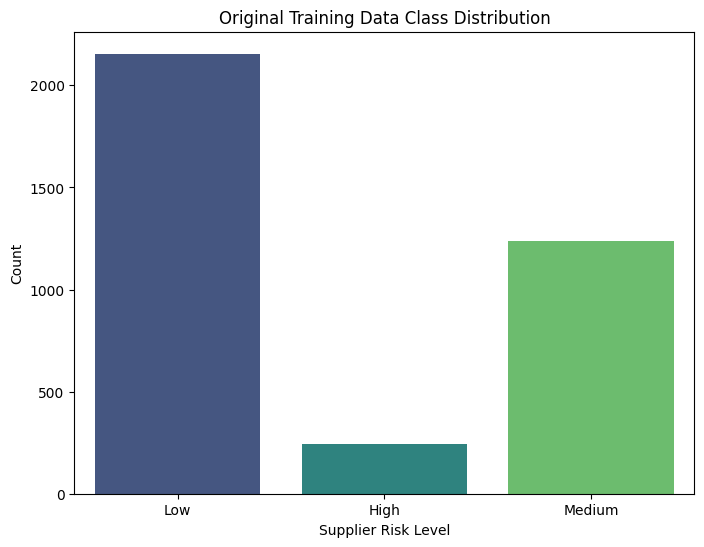


過採樣後訓練資料的類別分佈:
Counter({'Low': 2155, 'High': 2155, 'Medium': 2155})


/tmp/ipykernel_3904/199348134.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(resampled_counts.keys()), y=list(resampled_counts.values()), palette='viridis')


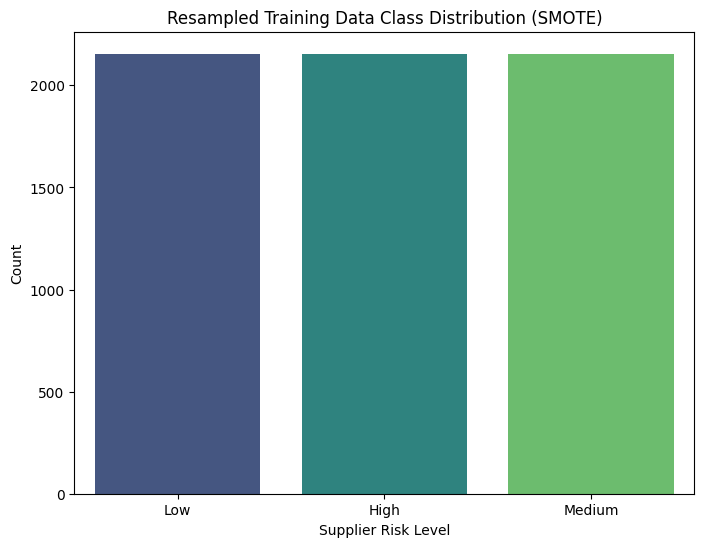


SMOTE 過採樣完成。
X_train_resampled 的形狀: (6465, 22)
y_train_resampled 的形狀: (6465,)


In [9]:
print('--- 檢查類別不平衡 (Imbalanced Data) 並進行重複取樣 ---')

import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 X_train_selected_scaled 和 y_train_selected 已經在之前的單元格中定義。
# 如果尚未定義，請確保執行了特徵選擇和標準化的單元格。

print("原始訓練資料 (y_train_selected) 的類別分佈:")
original_counts = Counter(y_train_selected)
print(original_counts)

# 視覺化原始類別分佈
plt.figure(figsize=(8, 6))
sns.barplot(x=list(original_counts.keys()), y=list(original_counts.values()), palette='viridis')
plt.title('Original Training Data Class Distribution')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.show()

# 初始化 SMOTE
# random_state 確保結果的可重現性
smote = SMOTE(random_state=42)

# 對訓練資料進行過採樣
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected_scaled, y_train_selected)

print("\n過採樣後訓練資料的類別分佈:")
resampled_counts = Counter(y_train_resampled)
print(resampled_counts)

# 視覺化過採樣後類別分佈
plt.figure(figsize=(8, 6))
sns.barplot(x=list(resampled_counts.keys()), y=list(resampled_counts.values()), palette='viridis')
plt.title('Resampled Training Data Class Distribution (SMOTE)')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.show()

print("\nSMOTE 過採樣完成。")
print(f"X_train_resampled 的形狀: {X_train_resampled.shape}")
print(f"y_train_resampled 的形狀: {y_train_resampled.shape}")

--- 開始使用 GridSearchCV 進行特徵選擇與模型調優 ---
開始擬合 GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV 擬合完成。

--- GridSearchCV 結果 ---
最佳參數 (Best Parameters): {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'feature_selection__k': 4}
最佳 F1-macro 分數 (Best F1-macro Score): 1.0000

由 GridSearchCV 選擇的最佳特徵:
- Supplier Tier（供應商層級）
- Supplier ESG Score（供應商ESG評分）
- Maverick Spend（脫軌採購）_Yes
- Preferred Supplier（優先供應商）_Yes

--- 評估最佳模型在測試集上的性能 ---
準確度 (Accuracy): 1.0000

分類報告 (Classification Report):

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       105
         Low       1.00      1.00      1.00       923
      Medium       1.00      1.00      1.00       532

    accuracy                           1.00      1560
   macro avg       1.00      1.00      1.00      1560
weighted avg       1.00      1.00      1.00      1560


混淆矩陣 (Confusion Matrix):



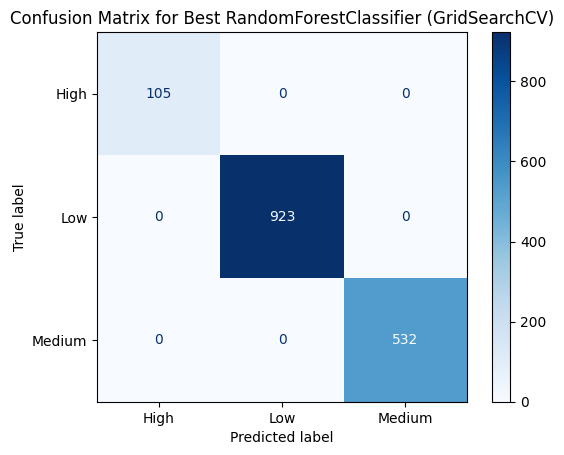

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("--- 開始使用 GridSearchCV 進行特徵選擇與模型調優 ---")

# 1. 定義 Pipeline
#    - SelectKBest: 用於選擇最佳的 K 個特徵，這裡使用 f_classif 統計檢定 (適用於分類任務)
#    - RandomForestClassifier: 作為最終的分類模型
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced_subsample'))
])

# 2. 定義參數網格 (Parameter Grid)
#    - feature_selection__k: 要選擇的特徵數量。可以嘗試不同的值，例如 2, 3, 'all' (所有特徵)。
#    - classifier__n_estimators: 隨機森林中的樹的數量。
#    - classifier__max_depth: 樹的最大深度。
param_grid = {
    'feature_selection__k': [2, 3, 4], # 嘗試選擇 2, 3 或 4 個特徵
    'classifier__n_estimators': [100, 200], # 嘗試 100 或 200 棵樹
    'classifier__max_depth': [5, 10] # 嘗試最大深度為 5 或 10
}

# 3. 初始化 GridSearchCV
#    - cv=5: 使用 5 折交叉驗證
#    - scoring='f1_macro': 使用 F1-macro 分數作為評估指標，適用於多類別不平衡資料集
#    - n_jobs=-1: 使用所有可用的 CPU 核心進行平行運算
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# 4. 訓練 (擬合) GridSearchCV
#    使用 X_train_selected_scaled 和 y_train_selected
print("開始擬合 GridSearchCV...")
grid_search.fit(X_train_selected_scaled, y_train_selected)
print("GridSearchCV 擬合完成。")

# 5. 輸出最佳參數和最佳分數
print("\n--- GridSearchCV 結果 ---")
print(f"最佳參數 (Best Parameters): {grid_search.best_params_}")
print(f"最佳 F1-macro 分數 (Best F1-macro Score): {grid_search.best_score_:.4f}")

# 6. 取得最佳模型
best_rf_model = grid_search.best_estimator_

# 7. 取得選擇的特徵
#    - 從最佳模型中提取 SelectKBest 轉換器
selected_features_mask = best_rf_model.named_steps['feature_selection'].get_support()
selected_feature_names = X_train_selected.columns[selected_features_mask]

print("\n由 GridSearchCV 選擇的最佳特徵:")
for feature in selected_feature_names:
    print(f"- {feature}")

# 8. 評估最佳模型在測試集上的性能
print("\n--- 評估最佳模型在測試集上的性能 ---")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_best = best_rf_model.predict(X_test_selected_scaled)

accuracy_best = accuracy_score(y_test_selected, y_pred_best)
print(f"準確度 (Accuracy): {accuracy_best:.4f}")

print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_best))

print("\n混淆矩陣 (Confusion Matrix):\n")
cm_best = confusion_matrix(y_test_selected, y_pred_best, labels=best_rf_model.named_steps['classifier'].classes_)
display_cm_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_rf_model.named_steps['classifier'].classes_)
display_cm_best.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best RandomForestClassifier (GridSearchCV)')
plt.show()

## 多類別分類模型（Multi-class Classification Model) 評估

### 隨機森林模型 (RandomForestClassifier)

In [11]:
# 使用隨機森林
from sklearn.ensemble import RandomForestClassifier

'''
# 初始化隨機森林模型
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
'''

# 建議調優參數組合
rf_model = RandomForestClassifier(
    n_estimators=200,      # 增加樹的數量，提升穩定性
    max_depth=10,          # 限制樹的深度，防止過度擬合 (可嘗試 5~15)
    min_samples_split=5,   # 節點分割所需的最小樣本數
    class_weight='balanced_subsample', # 比 'balanced' 更適合隨機森林的抽樣特性
    random_state=42
)
model_selected = rf_model


# 訓練
rf_model.fit(X_train_selected_scaled, y_train_selected)

# 預測與評估
y_pred_selected = rf_model.predict(X_test_selected_scaled)
y_pred_selected_rf = y_pred_selected



### 邏輯回歸模型 (LogisticRegression)

In [12]:
from sklearn.linear_model import LogisticRegression

# 2. 初始化邏輯回歸模型
#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。
#   - class_weight='balanced': 自動調整類別權重，以應對類別不平衡問題。
lr_model = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
model_selected= lr_model


# 3. 訓練模型
print("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")
lr_model.fit(X_train_selected_scaled, y_train_selected)
print("模型訓練完成。")

# 4. 進行預測
print("\n開始進行預測 (使用 X_selected)...")
y_pred_selected = lr_model.predict(X_test_selected_scaled)
y_pred_selected_lr = y_pred_selected


開始訓練 Logistic Regression 模型 (使用 X_selected)...
模型訓練完成。

開始進行預測 (使用 X_selected)...


### 支持向量機 （SVM）


--- Support Vector Machine (SVM) Model ---
Resampled training data (X_train_resampled, y_train_resampled) already available.
開始訓練 Support Vector Machine (SVM) 模型...
模型訓練完成。

--- SVM 模型評估 ---
準確度 (Accuracy): 0.8083

分類報告 (Classification Report):

              precision    recall  f1-score   support

        High       0.50      0.76      0.60       105
         Low       0.99      0.80      0.88       923
      Medium       0.68      0.84      0.75       532

    accuracy                           0.81      1560
   macro avg       0.72      0.80      0.75      1560
weighted avg       0.85      0.81      0.82      1560


混淆矩陣 (Confusion Matrix):



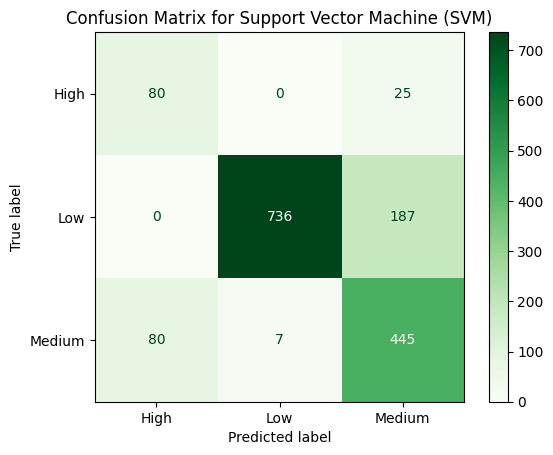

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter

print("\n--- Support Vector Machine (SVM) Model ---")

# Check if resampled data is available; if not, re-run SMOTE
if 'X_train_resampled' not in locals() or 'y_train_resampled' not in locals():
    print("\nWarning: X_train_resampled or y_train_resampled not found. Attempting to re-run SMOTE oversampling...")

    # Check if the necessary scaled and split data are available
    if 'X_train_selected_scaled' not in locals() or 'y_train_selected' not in locals() or \
       'X_test_selected_scaled' not in locals() or 'y_test_selected' not in locals():
        print("\nError: Required variables 'X_train_selected_scaled', 'y_train_selected', 'X_test_selected_scaled', or 'y_test_selected' are not defined.")
        print("Please ensure that the data splitting (cell cWwQ2XAf5V-K) and feature scaling (cell 32eb669e) cells have been executed successfully.")
        raise NameError("Required data for SMOTE oversampling or SVM prediction is missing. Please run previous cells.")

    # If inputs for SMOTE are available, proceed with SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected_scaled, y_train_selected)
    print("SMOTE oversampling re-completed. Resampled training data shape:")
    print(f"X_train_resampled: {X_train_resampled.shape}, y_train_resampled: {y_train_resampled.shape}")
    print(f"Resampled class distribution: {Counter(y_train_resampled)}")
else:
    print("Resampled training data (X_train_resampled, y_train_resampled) already available.")


# 1. 初始化 SVM 模型
#   - class_weight='balanced': 自動調整類別權重，以應對類別不平衡問題。
#   - kernel='rbf': 使用徑向基函數核 (Radial Basis Function kernel)，適用於非線性分類。
#   - random_state: 確保結果的可重現性。
svm_model = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model_selected = svm_model


# 2. 訓練模型
print("開始訓練 Support Vector Machine (SVM) 模型...")
svm_model.fit(X_train_resampled, y_train_resampled) # 使用 SMOTE 過採樣後的數據進行訓練
print("模型訓練完成。")

# 3. 進行預測
y_pred_svm = svm_model.predict(X_test_selected_scaled)
y_pred_selected_svm = y_pred_selected = y_pred_svm
# y_pred_selected_svm = y_pred_selected


# '''
# 4. 評估模型性能
print("\n--- SVM 模型評估 ---")

# 準確度
accuracy_svm = accuracy_score(y_test_selected, y_pred_svm)
print(f"準確度 (Accuracy): {accuracy_svm:.4f}")

# 分類報告 (包含精確度、召回率、F1-score)
print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_svm))

# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")
cm_svm = confusion_matrix(y_test_selected, y_pred_svm, labels=svm_model.classes_)
display_cm_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
display_cm_svm.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Support Vector Machine (SVM)')
plt.show()
# '''

## 評估模型性能


--- 模型評估 (使用 X_selected) ---
準確度 (rf Accuracy): 0.9622
準確度 (lr Accuracy): 0.8359
準確度 (svm Accuracy): 0.8083

分類報告 (rf Classification Report):

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       105
         Low       1.00      0.94      0.97       923
      Medium       0.90      1.00      0.95       532

    accuracy                           0.96      1560
   macro avg       0.97      0.98      0.97      1560
weighted avg       0.97      0.96      0.96      1560


分類報告 (lr Classification Report):

              precision    recall  f1-score   support

        High       0.49      1.00      0.65       105
         Low       0.97      0.87      0.92       923
      Medium       0.77      0.74      0.75       532

    accuracy                           0.84      1560
   macro avg       0.74      0.87      0.78      1560
weighted avg       0.87      0.84      0.84      1560


分類報告 (svm Classification Report):

              precision

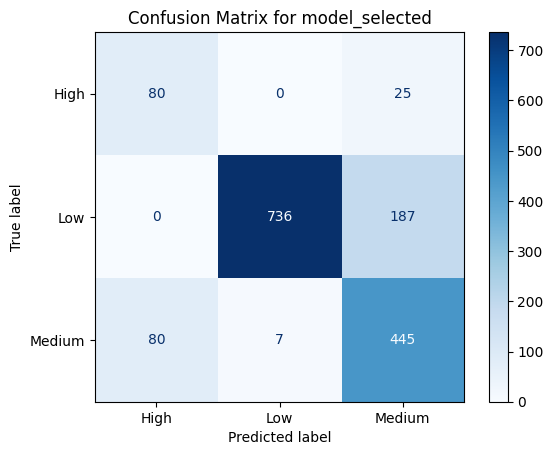

In [14]:
from sklearn.metrics import accuracy_score


# 5. 評估模型性能
print("\n--- 模型評估 (使用 X_selected) ---")

# 準確度
# accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
accuracy_selected_rf = accuracy_score(y_test_selected, y_pred_selected_rf)
accuracy_selected_lr = accuracy_score(y_test_selected, y_pred_selected_lr)
accuracy_selected_svm = accuracy_score(y_test_selected, y_pred_selected_svm)

# print(f"準確度 (Accuracy): {accuracy_selected:.4f}")
print(f"準確度 (rf Accuracy): {accuracy_selected_rf:.4f}")
print(f"準確度 (lr Accuracy): {accuracy_selected_lr:.4f}")
print(f"準確度 (svm Accuracy): {accuracy_selected_svm:.4f}")



# 分類報告 (包含精確度、召回率、F1-score)
# print("\n分類報告 (Classification Report):\n")
# print(classification_report(y_test_selected, y_pred_selected))
print("\n分類報告 (rf Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected_rf))

print("\n分類報告 (lr Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected_lr))

print("\n分類報告 (svm Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected_svm))




# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")

# model selection:
# model=lr_model
# model=rf_model

cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)
# cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model.classes_)

display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model_selected.classes_)
# display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model.classes_)
display_cm_selected.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for model_selected')
plt.show()